In [1]:
# ============================================================
# PROJECT: Customer Segmentation using K-Means Clustering
# Week 4 - Major Capstone Project
# ============================================================

# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [2]:
# ============================================================
# Load the Dataset
# ============================================================

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# ============================================================
# Display First Five Rows
# ============================================================

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# ============================================================
# Display Last Five Rows
# ============================================================

df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# ============================================================
# Shape of Dataset
# ============================================================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [7]:
# ============================================================
# Data Types
# ============================================================

df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [9]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [10]:
# ============================================================
# Check Missing Values
# ============================================================

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
# ============================================================
# Check Duplicate Values
# ============================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
# ============================================================
# Remove Duplicate Rows
# ============================================================

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates :", df.shape)

Dataset Shape After Removing Duplicates : (200, 5)


In [13]:
# ============================================================
# Encode Gender Column
# ============================================================

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [15]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation = df.corr(numeric_only=True)
correlation

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,0.057400,-0.026763,0.977548,0.013835
Gender,0.057400,1.000000,0.060867,0.056410,-0.058109
Age,-0.026763,0.060867,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,0.056410,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.058109,-0.327227,0.009903,1.000000


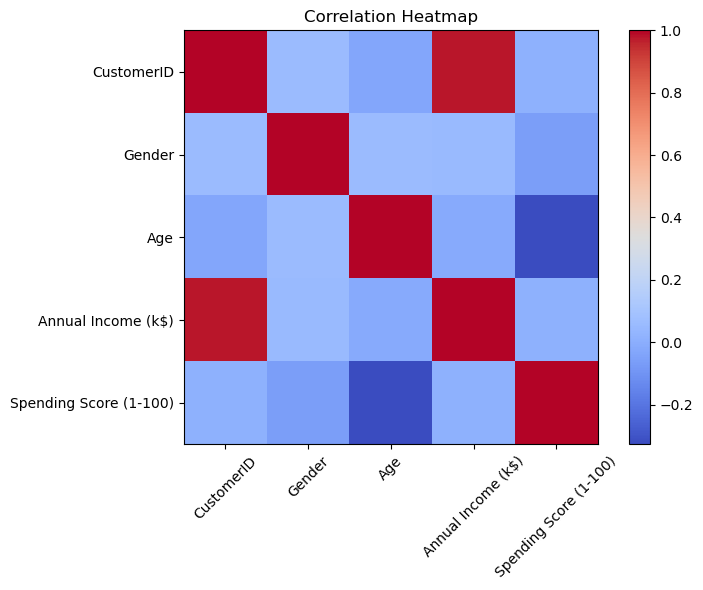

In [16]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

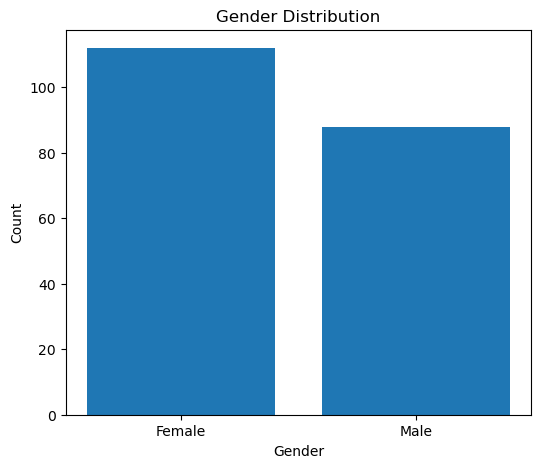

In [17]:
# ============================================================
# Gender Distribution
# ============================================================

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(["Female","Male"], gender_counts)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

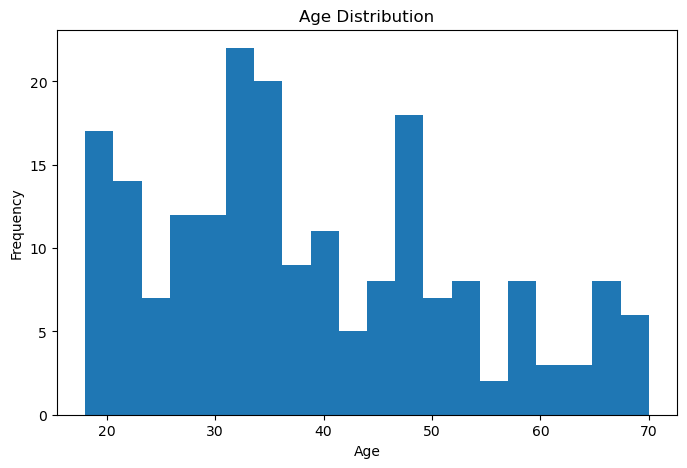

In [18]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

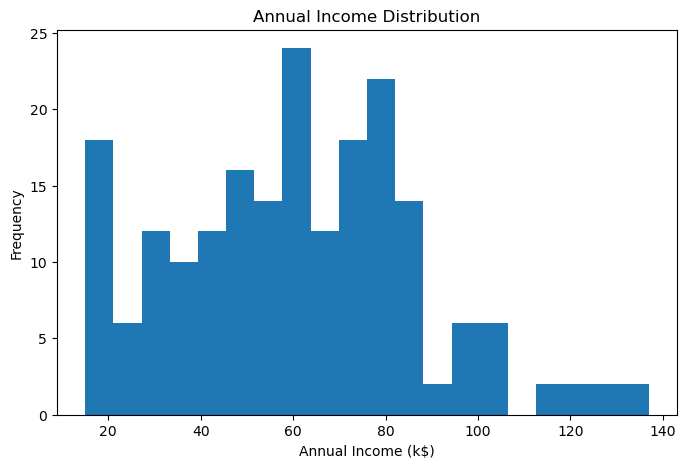

In [19]:
# ============================================================
# Annual Income Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

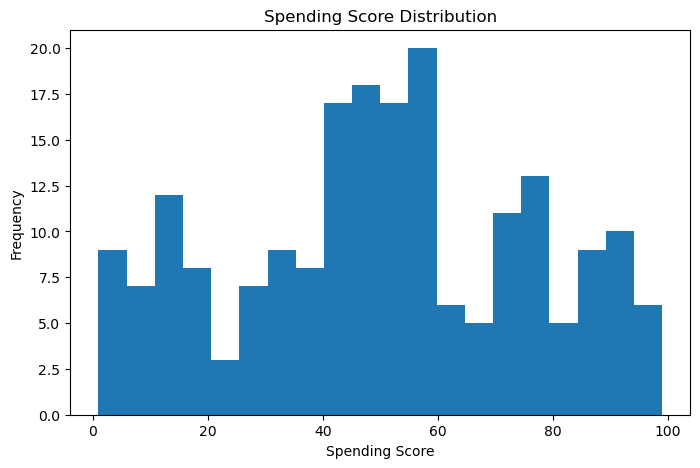

In [20]:
# ============================================================
# Spending Score Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

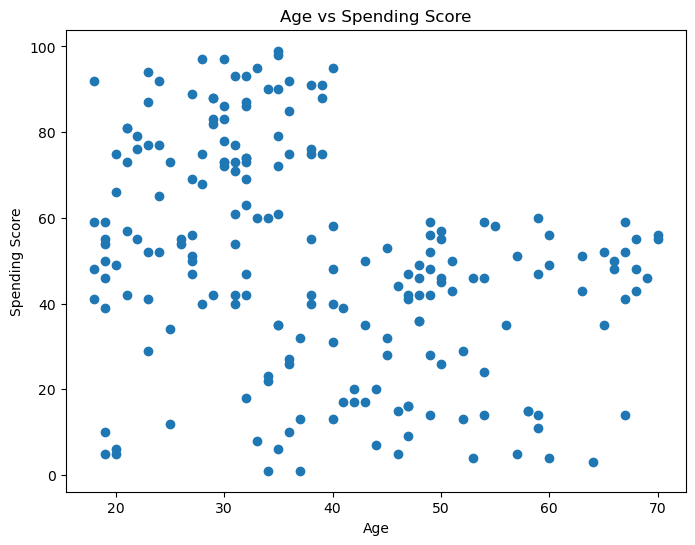

In [21]:
# ============================================================
# Age vs Spending Score
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()

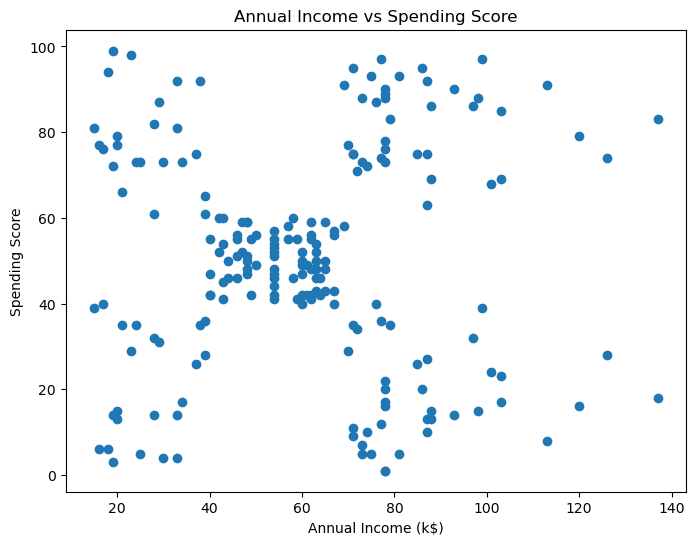

In [22]:
# ============================================================
# Annual Income vs Spending Score
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [23]:
# ============================================================
# Feature Selection
# ============================================================

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [24]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


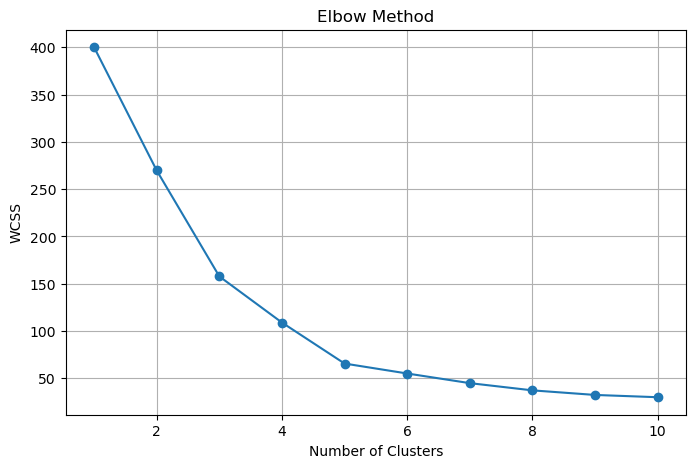

In [25]:
# ============================================================
# Elbow Method
# ============================================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [26]:
# ============================================================
# Train K-Means Clustering Model
# ============================================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means Model Trained Successfully!")

K-Means Model Trained Successfully!


In [27]:
# ============================================================
# Predict Customer Clusters
# ============================================================

df["Cluster"] = kmeans.predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


In [28]:
# ============================================================
# Number of Customers in Each Cluster
# ============================================================

print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [29]:
# ============================================================
# Cluster Centers (Scaled Data)
# ============================================================

print(kmeans.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [30]:
# ============================================================
# Cluster Centers in Original Scale
# ============================================================

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

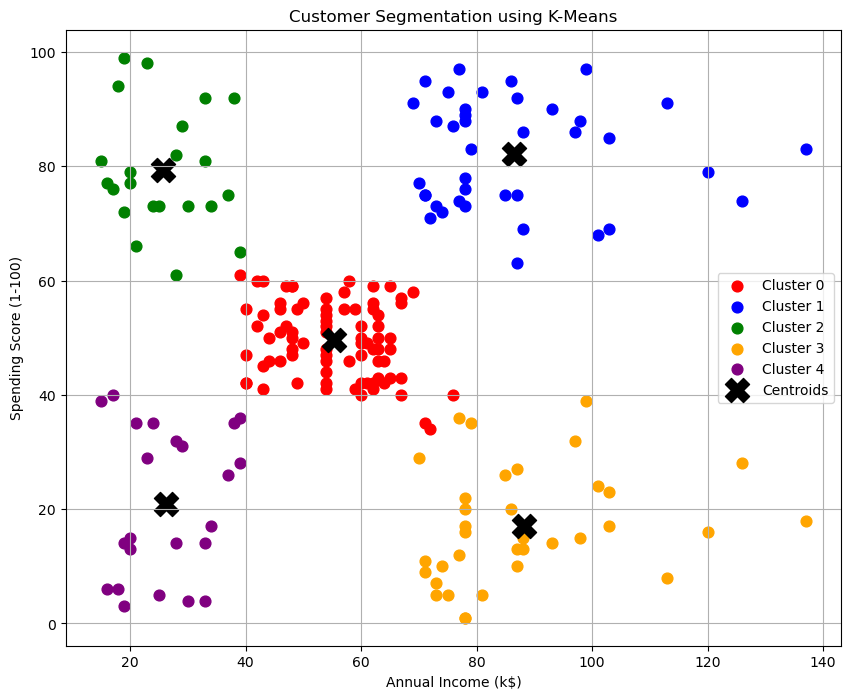

In [31]:
# ============================================================
# Customer Segmentation using K-Means
# ============================================================

plt.figure(figsize=(10,8))

colors = ['red','blue','green','orange','purple']

for i in range(5):
    
    plt.scatter(
        df[df["Cluster"] == i]["Annual Income (k$)"],
        df[df["Cluster"] == i]["Spending Score (1-100)"],
        s=60,
        color=colors[i],
        label=f"Cluster {i}"
    )

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    marker='X',
    color='black',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
# ============================================================
# Evaluate Clustering Performance
# ============================================================

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score :", round(score,3))

Silhouette Score : 0.555


In [33]:
# ============================================================
# Assign Meaningful Cluster Labels
# ============================================================

cluster_names = {
    0: "Premium Customers",
    1: "High Spenders",
    2: "Average Customers",
    3: "Careful Customers",
    4: "Low Spenders"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,1,19,15,39,4,Low Spenders
1,2,1,21,15,81,2,Average Customers
2,3,0,20,16,6,4,Low Spenders
3,4,0,23,16,77,2,Average Customers
4,5,0,31,17,40,4,Low Spenders


In [34]:
# ============================================================
# Customer Segment Distribution
# ============================================================

df["Customer Segment"].value_counts()

Customer Segment
Premium Customers    81
High Spenders        39
Careful Customers    35
Low Spenders         23
Average Customers    22
Name: count, dtype: int64

In [35]:
# ============================================================
# Save Final Dataset
# ============================================================

df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("File Saved Successfully!")

File Saved Successfully!


In [36]:
# ============================================================
# Final Dataset
# ============================================================

df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,1,19,15,39,4,Low Spenders
1,2,1,21,15,81,2,Average Customers
2,3,0,20,16,6,4,Low Spenders
3,4,0,23,16,77,2,Average Customers
4,5,0,31,17,40,4,Low Spenders
5,6,0,22,17,76,2,Average Customers
6,7,0,35,18,6,4,Low Spenders
7,8,0,23,18,94,2,Average Customers
8,9,1,64,19,3,4,Low Spenders
9,10,0,30,19,72,2,Average Customers


In [37]:
# ============================================================
# Project Conclusion
# ============================================================

print("PROJECT COMPLETED SUCCESSFULLY")

print("\nKey Findings:")
print("- Customer data was cleaned and preprocessed.")
print("- Features were standardized before clustering.")
print("- The Elbow Method suggested an optimal number of clusters.")
print("- K-Means successfully segmented customers into five groups.")
print("- Customer segments can help businesses create targeted marketing strategies.")
print("- The final clustered dataset has been saved for future analysis.")

PROJECT COMPLETED SUCCESSFULLY

Key Findings:
- Customer data was cleaned and preprocessed.
- Features were standardized before clustering.
- The Elbow Method suggested an optimal number of clusters.
- K-Means successfully segmented customers into five groups.
- Customer segments can help businesses create targeted marketing strategies.
- The final clustered dataset has been saved for future analysis.


In [38]:
# ============================================================
# Cluster-wise Summary Statistics
# ============================================================

cluster_summary = df.groupby("Customer Segment")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

print(cluster_summary)

                     Age  Annual Income (k$)  Spending Score (1-100)
Customer Segment                                                    
Average Customers  25.27               25.73                   79.36
Careful Customers  41.11               88.20                   17.11
High Spenders      32.69               86.54                   82.13
Low Spenders       45.22               26.30                   20.91
Premium Customers  42.72               55.30                   49.52


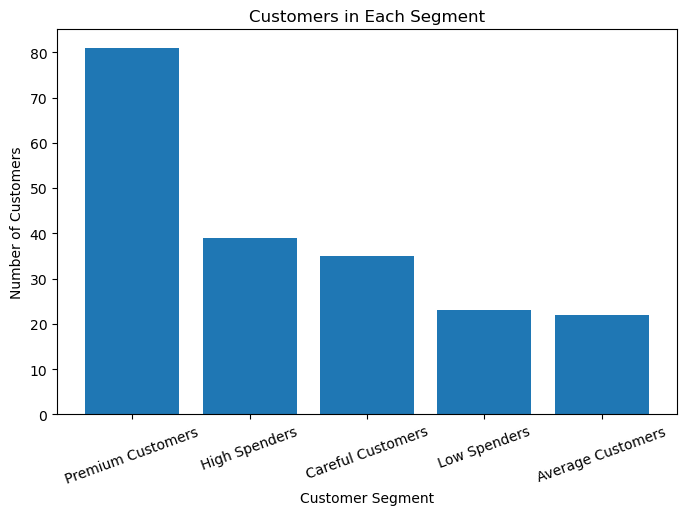

In [39]:
# ============================================================
# Number of Customers in Each Segment
# ============================================================

segment_count = df["Customer Segment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(segment_count.index, segment_count.values)

plt.title("Customers in Each Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

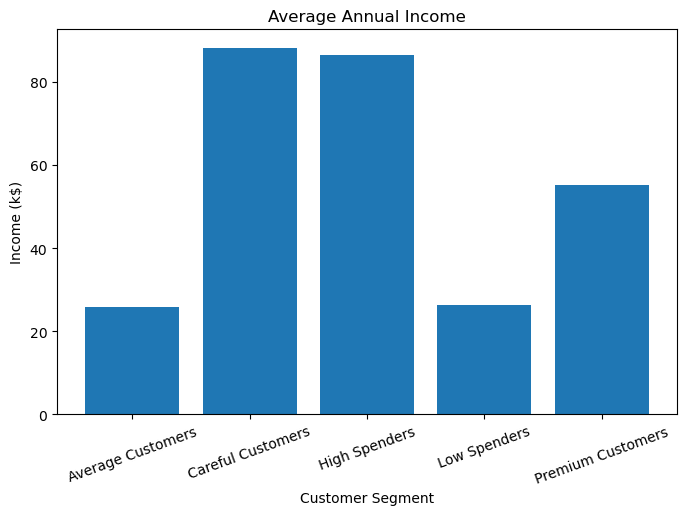

In [40]:
# ============================================================
# Average Annual Income by Segment
# ============================================================

income = df.groupby("Customer Segment")["Annual Income (k$)"].mean()

plt.figure(figsize=(8,5))

plt.bar(income.index, income.values)

plt.title("Average Annual Income")

plt.xlabel("Customer Segment")

plt.ylabel("Income (k$)")

plt.xticks(rotation=20)

plt.show()

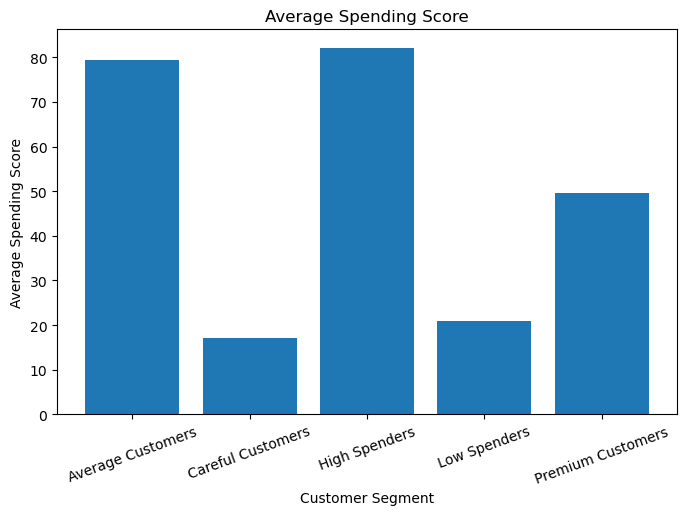

In [41]:
# ============================================================
# Average Spending Score
# ============================================================

spending = df.groupby("Customer Segment")["Spending Score (1-100)"].mean()

plt.figure(figsize=(8,5))

plt.bar(spending.index, spending.values)

plt.title("Average Spending Score")

plt.xlabel("Customer Segment")

plt.ylabel("Average Spending Score")

plt.xticks(rotation=20)

plt.show()

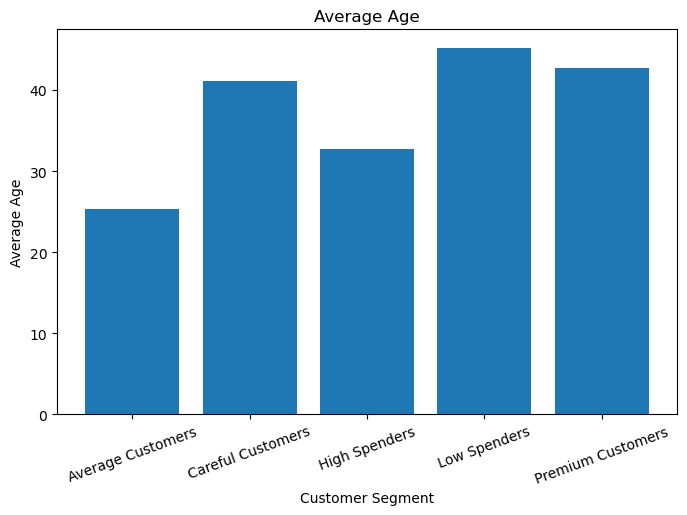

In [42]:
# ============================================================
# Average Age by Customer Segment
# ============================================================

age = df.groupby("Customer Segment")["Age"].mean()

plt.figure(figsize=(8,5))

plt.bar(age.index, age.values)

plt.title("Average Age")

plt.xlabel("Customer Segment")

plt.ylabel("Average Age")

plt.xticks(rotation=20)

plt.show()

In [43]:
# ============================================================
# Cluster Summary Table
# ============================================================

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Customer Segment,,,
Average Customers,25.27,25.73,79.36
Careful Customers,41.11,88.20,17.11
High Spenders,32.69,86.54,82.13
Low Spenders,45.22,26.30,20.91
Premium Customers,42.72,55.30,49.52


In [44]:
# ============================================================
# Business Insights
# ============================================================

print("BUSINESS INSIGHTS\n")

print("1. Premium Customers")
print("- High income and high spending.")
print("- Best customers for premium products and loyalty programs.\n")

print("2. High Spenders")
print("- Moderate income but high spending.")
print("- Respond well to discounts and promotional offers.\n")

print("3. Average Customers")
print("- Average income and average spending.")
print("- Can be targeted with regular marketing campaigns.\n")

print("4. Careful Customers")
print("- High income but low spending.")
print("- Potential customers who may be encouraged through exclusive offers.\n")

print("5. Low Spenders")
print("- Low income and low spending.")
print("- Focus on budget-friendly products.")

BUSINESS INSIGHTS

1. Premium Customers
- High income and high spending.
- Best customers for premium products and loyalty programs.

2. High Spenders
- Moderate income but high spending.
- Respond well to discounts and promotional offers.

3. Average Customers
- Average income and average spending.
- Can be targeted with regular marketing campaigns.

4. Careful Customers
- High income but low spending.
- Potential customers who may be encouraged through exclusive offers.

5. Low Spenders
- Low income and low spending.
- Focus on budget-friendly products.


In [45]:
# ============================================================
# Future Scope
# ============================================================

print("""
Future Improvements

• Use larger customer datasets.
• Apply DBSCAN and Hierarchical Clustering.
• Build an interactive dashboard using Streamlit.
• Deploy the model on the web.
• Integrate customer segmentation into CRM systems.
• Perform real-time customer segmentation.
""")


Future Improvements

• Use larger customer datasets.
• Apply DBSCAN and Hierarchical Clustering.
• Build an interactive dashboard using Streamlit.
• Deploy the model on the web.
• Integrate customer segmentation into CRM systems.
• Perform real-time customer segmentation.



In [46]:
# ============================================================
# Final Conclusion
# ============================================================

print("""
Customer segmentation using K-Means Clustering was successfully performed.

The workflow included:

✔ Data Cleaning
✔ Data Visualization
✔ Feature Selection
✔ Feature Scaling
✔ Elbow Method
✔ K-Means Clustering
✔ Cluster Visualization
✔ Business Insights

The generated customer segments help businesses understand customer behavior and enable targeted marketing strategies, improving customer satisfaction and business growth.
""")


Customer segmentation using K-Means Clustering was successfully performed.

The workflow included:

✔ Data Cleaning
✔ Data Visualization
✔ Feature Selection
✔ Feature Scaling
✔ Elbow Method
✔ K-Means Clustering
✔ Cluster Visualization
✔ Business Insights

The generated customer segments help businesses understand customer behavior and enable targeted marketing strategies, improving customer satisfaction and business growth.



In [47]:
# ============================================================
# Export Cluster Summary
# ============================================================

cluster_summary.to_csv("Cluster_Summary.csv")

print("Cluster Summary Saved Successfully.")

Cluster Summary Saved Successfully.
